# Python for Healthcare Analytics - Assignment 1
## Exploratory Analysis of Hospital Claims


**AI-use disclosure:** Claude (Anthropic) in Visual Studio  was used to help develop the code in this notebook with  manual additions,  it was done working through the assignment part by part. The written interpretations are my own.


## Part A - Load & Inspect

Part A - Load & Inspect (10 pts)

1. Load the dataset and report its shape (rows × columns).

2. Display the column names and their data types. Identify which columns holding dates are currently stored as text.

3. Report the number of missing values per column and state which column(s) are affected.

4. Print summary statistics for TotalExpenses and describe its distribution in one sentence (mean vs. median)

**PA-A1. Load the dataset and report its shape.**

In [26]:
import pandas as pd

# Load the claims data directly from the source URL given in the brief
url = ('https://github.com/thousandoaks/Python4DS-I/'
       'raw/main/datasets/HealthcareDataset_PublicRelease.csv')
df = pd.read_csv(url)

print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (52563, 17)


**PA-A2. Column names and dtypes — which date columns are stored as text?**

In [27]:
# Show every column and its data type
print(df.dtypes)

# The three date fields should be datetimes; check whether they are still text
date_fields = ['StartDate', 'EndDate', 'BirthDate']
stored_as_text = [dte for dte in date_fields
                  if not pd.api.types.is_datetime64_any_dtype(df[dte])]
print()
print('Date columns currently stored as text:', stored_as_text)

Id                          int64
MemberName                    str
MemberID                      str
County                        str
MedicalClaim                  str
ClaimItem                   int64
HospitalName                  str
HospitalType                  str
StartDate                     str
EndDate                       str
PrincipalDiagnosisDesc        str
PrincipalDiagnosis            str
RevenueCodeDesc               str
RevenueCode               float64
TypeFlag                      str
BirthDate                     str
TotalExpenses             float64
dtype: object

Date columns currently stored as text: ['StartDate', 'EndDate', 'BirthDate']


*TODO - which date columns are stored as text.

The columns that are string rather than date are 'StartDate' ,'EndDate' and Birthdate  

**PA-A3. Mi-sing values per column.**

In [28]:
# Count missing values in each column and name the affected column(s)
missing = df.isna().sum()
print(missing)
print()
print('Columns with missing values:', list(missing[missing > 0].index))

Id                        0
MemberName                0
MemberID                  0
County                    0
MedicalClaim              0
ClaimItem                 0
HospitalName              0
HospitalType              0
StartDate                 0
EndDate                   0
PrincipalDiagnosisDesc    0
PrincipalDiagnosis        0
RevenueCodeDesc           2
RevenueCode               0
TypeFlag                  0
BirthDate                 0
TotalExpenses             0
dtype: int64

Columns with missing values: ['RevenueCodeDesc']


*TODO Report the number of missing values per column and state which column(s) are affected.*

The column that has missing values is 'RevenueCodeDesc' has shown above.   It is showing 2 missing Values.

**PA-A4. Summary statistics for TotalExpenses.**

In [29]:
# Summary statistics for the cost variable
df['TotalExpenses'].describe()

count     52563.000000
mean       2735.230373
std        8292.178928
min           0.000000
25%         194.642000
50%         675.262000
75%        2309.265000
max      504533.400000
Name: TotalExpenses, dtype: float64

*TODO — describe the distribution's shape by comparing the mean to the median what does mean >> median imply about skew?.*

Totalexenses is heavily right-schewed the 'Mean'  £2735 value is appox 4 times the 'Medain' value of  £675, the Maximum is £504533 (60 std deviations above the median)  indicating a heavily right shewed distribution most likely couase by a small number of Spenders.



## Part B - Filtering 
Part B - Filtering (15 pts)

1. Create a DataFrame containing only emergency (TypeFlag == 'ER') line items. How many rows?

2. From the full dataset, select all line items with TotalExpenses greater than $10,000. How many are there, and what share of total spend do they represent?

3. Using a compound condition, filter for inpatient (INP) line items at a HospitalType of REHABILITATION CENTER. Show the result.

4. Filter the data to the month of January 2020 using the parsed StartDate column. Report the row count.

**Preparation: parse the date columns.** These are needed for the date filter below and the derived columns in Part E.

In [30]:
# Convert the three text date columns to proper datetimes
for col in ['StartDate', 'EndDate', 'BirthDate']:
    df[col] = pd.to_datetime(df[col])

df[['StartDate', 'EndDate', 'BirthDate']].dtypes

StartDate    datetime64[us]
EndDate      datetime64[us]
BirthDate    datetime64[us]
dtype: object

**PB-B1. Emergency (ER) line items only.**

In [31]:
# Single-condition filter: keep only emergency line items
er_items = df[df['TypeFlag'] == 'ER']
print('ER line items:', len(er_items))

ER line items: 23978


*Create a DataFrame containing only emergency (TypeFlag == 'ER') line items. How many rows?*

There are 23978 rows that are available once filtered by 'ER'

**PB-B2. Line items over \$10,000 and their share of total spend.**

In [32]:
# Filter to high-cost line items, then compute their share of all spend
high_cost = df[df['TotalExpenses'] > 10000]
share = high_cost['TotalExpenses'].sum() / df['TotalExpenses'].sum()
print('Line items over $10,000:', len(high_cost))
print(f'Share of total spend: {share:.1%}')

Line items over $10,000: 3090
Share of total spend: 51.1%


*TODO - a small number of line items account for what share of spend — what does that say about cost concentration?*

There are 3090 line items  that are over $10,000 and these represent 51.1% of the overall totalexpenses spend,

**PB-B3. Compound condition: inpatient line items at rehabilitation centers.**

In [33]:
# Compound filter: both conditions must hold (note the parentheses around each)
rehab_inp = df[(df['TypeFlag'] == 'INP') &
               (df['HospitalType'] == 'REHABILITATION CENTER')]
print('Rows:', len(rehab_inp))
rehab_inp.head()

Rows: 20


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,PrincipalDiagnosisDesc,PrincipalDiagnosis,RevenueCodeDesc,RevenueCode,TypeFlag,BirthDate,TotalExpenses
4664,642704,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,12,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,OTHER THERAPEUTIC SERV,940.0,INP,1952-05-19,41.090
4666,642706,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,2,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,REHAB,128.0,INP,1952-05-19,4674.600
4679,642767,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,3,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,PHARMACY,250.0,INP,1952-05-19,760.368
4680,642768,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,4,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,MEDICAL/SURGICAL SUPPLIES,270.0,INP,1952-05-19,331.226
4681,642769,729c3184,6cf57dc3,ea48569b,d2e1e1dd74879ef7,10,2aabe637,REHABILITATION CENTER,2020-01-04,2020-01-11,Other sequelae of cerebra,I69.398,SPEECH-LANGUAGE PATHOLOGY,440.0,INP,1952-05-19,544.950


**PB-B4. Line items starting in January 2020.**

In [34]:
# Date-based filter on the parsed StartDate column
jan_2020 = df[(df['StartDate'] >= '2020-01-01') & (df['StartDate'] <= '2020-01-31')]
print('Line items starting in January 2020:', len(jan_2020))

Line items starting in January 2020: 6788


## Part C - Group By & Aggregation

Part C - Group By & Aggregation (20 pts)

1. Group by TypeFlag and compute the count, mean, and sum of TotalExpenses. Which category costs more per line item on average?

2. Group by County and compute total spend. Report the five highest-spending counties.

3. Group by PrincipalDiagnosisDesc and count line items. Report the ten most frequent principal diagnoses.

4. Using groupby on two keys (HospitalType and TypeFlag), compute mean TotalExpenses. Present the result as a readable table.


**PC-C1. Count, mean and sum of TotalExpenses by TypeFlag.**

In [35]:
# Group by TypeFlag and compute count, mean, and sum of TotalExpenses
by_type = df.groupby('TypeFlag')['TotalExpenses'].agg(['count', 'mean', 'sum'])

# Identify the category with the highest average cost per line item
priciest = by_type['mean'].idxmax()
print(by_type.round(2))
print(f"\nHighest average cost per line item: {priciest} (${by_type['mean'].max():,.2f})")

          count     mean          sum
TypeFlag                             
ER        23978   923.92   22153669.6
INP       28585  4254.62  121618244.5

Highest average cost per line item: INP ($4,254.62)


*TODO - which category (INP or ER) costs more per line item on average, and roughly by how much.*

Inpatient (INP) is far more per line item on average $4,254.617 against $923.916 INP is appox 4.6 higher than ER.   The main reason for this is ER is usually a a single visit,  Inpatient  involves overbight stays, procedures.

**PC-C2. Five highest-spending counties.**

In [36]:
# Total spend per county, sorted, top five
top_counties = (df.groupby('County')['TotalExpenses']
                  .sum()
                  .sort_values(ascending=False)
                  .head(5))
top_counties

County
02af982d    6.965805e+07
425a37b2    2.389492e+07
fd218584    1.641345e+07
89e38653    8.851130e+06
b021dd12    6.025211e+06
Name: TotalExpenses, dtype: float64

*

**PC-C3. Ten most frequent principal diagnoses.**

In [37]:
# Frequency count of line items per principal diagnosis
top10 = df.groupby('PrincipalDiagnosisDesc').size().sort_values(ascending=False).head(10)
top10


PrincipalDiagnosisDesc
Other chest pain             2608
Sepsis unspecified organi    2046
Chronic obstructive pulmo    1372
Atherosclerotic heart dis    1241
Hypertensive heart and ch    1126
COVID-19                     1064
Acute kidney failure unsp    1017
Type 2 diabetes mellitus     1011
Non-ST elevation (NSTEMI)     992
Hypertensive heart diseas     972
dtype: int64

**PC-C4. Mean TotalExpenses by HospitalType and TypeFlag.**

In [38]:
# Two-key groupby → pivot, formatted as a readable currency table
pivot = df.pivot_table(index='HospitalType', columns='TypeFlag',
                       values='TotalExpenses', aggfunc='mean')

readable = pivot.map(lambda x: f'${x:,.2f}' if pd.notna(x) else 'n/a')
readable.index.name = 'Hospital Type'
readable.columns.name = 'Mean TotalExpenses'
readable

Mean TotalExpenses,ER,INP
Hospital Type,,
HOSPITAL,$923.92,"$4,254.33"
HOSPITAL LONG TERM ACUTE,n/a,"$5,411.28"
REHABILITATION CENTER,n/a,"$1,248.30"


*Note: the NaN cells are combinations that do not occur in the data  'long-term acute' and 'rehabilitation' facilities have no ER line items.*

## Part D - Visualisation with seaborn

Part D - Visualization with seaborn (20 pts)

Each plot must have a title and labeled axes. Add a one-sentence markdown interpretation under each.

1. Histogram of TotalExpenses. Because the variable is highly skewed, restrict the x-axis (e.g., to the 0–5,000 range) or plot the log of expenses so the shape is visible.

2. Boxplot of TotalExpenses by TypeFlag (INP vs. ER). Comment on the difference in spread and medians.

3. Scatterplot. Line-item expenses and length of stay are at different grains, so first aggregate to one row per claim (group by MedicalClaim): sum TotalExpenses into a claim total and take the stay length. Then scatter total claim cost (y) against LengthOfStay (x), colored by TypeFlag. Use the length-of-stay field you derive in Part E, and describe the relationship you see.

**PD-D1. Histogram of TotalExpenses** (x-axis restricted to 0–5,000 so the shape is visible despite the skew).

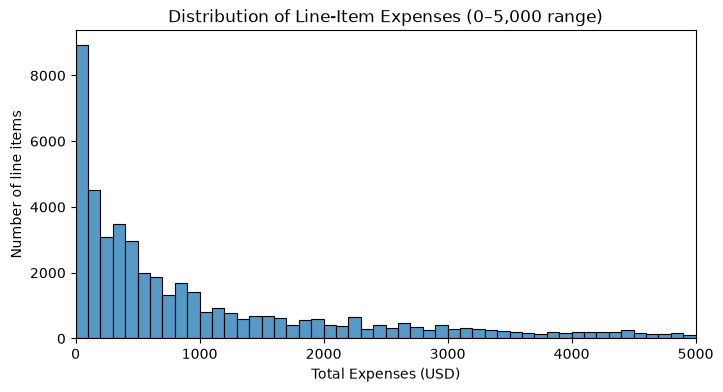

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of the cost variable, restricted to the 0-5,000 range per the brief
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='TotalExpenses', bins=50, binrange=(0, 5000))
plt.xlim(0, 5000)
plt.title('Distribution of Line-Item Expenses (0–5,000 range)')
plt.xlabel('Total Expenses (USD)')
plt.ylabel('Number of line items')
plt.show()

*TODO - describe the shape where most line items sit, direction of the tail.*

This is a histogram of the distribution of line-item expenses, restricted to the $0 to 5,000 range, it shows a classic right-skewed (positively skewed) distribution.

What it's telling you:

Most line items in the dataset are cheap. The tallest bar sits at the very left and shows over   8,000 line items cost under ~$100–150, and the bars fall off steeply from there. The bulk of activity is low-cost claims (routine ER visits, minor services would be the ssumption baed from these results).

Long right tail. As  line items get more expensive, show one the graph is  a thin, steady stream of items stretching out to $5,000.   A small number of expensive claims carry disproportionate weight.

This mainly becuase the following reasons.

- the mean sits well above the median (the average is pulled up by the tail),
- 51% of all spend came from just over 3,090 items  that cost over $10,000 (from the earlier question),

The x-axis is deliberately capped at $5,000.  Without that cap, the extreme high-cost claims would stretch the axis so far that this dense low-cost region would collapse into a single unreadable spike. 

Healthcare spending here is highly concentrated in the small claims (ER) the vast majority of claims are small, whilst a small minority of high-cost claims dominate total  and cuase the output without further anlaysis to be schewed.. For analysis that means summary statistics like the mean are misleading on their own.

**PD-D2. Boxplot of TotalExpenses by TypeFlag.** A log scale is used on the y-axis so the medians and spread are visible despite extreme outliers.

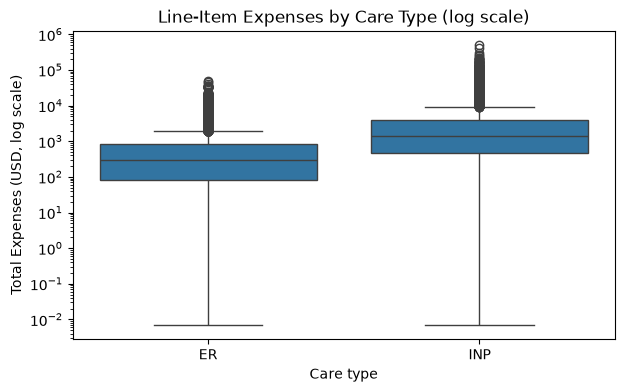

In [40]:
# Boxplot comparing inpatient vs emergency costs; log scale handles the skew
plt.figure(figsize=(7, 4))
sns.boxplot(data=df[df['TotalExpenses'] > 0], x='TypeFlag', y='TotalExpenses')
plt.yscale('log')
plt.title('Line-Item Expenses by Care Type (log scale)')
plt.xlabel('Care type')
plt.ylabel('Total Expenses (USD, log scale)')
plt.show()

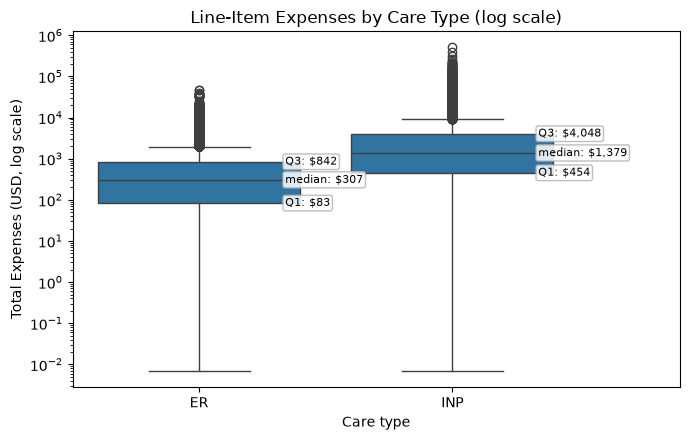

In [41]:
 #Boxplot comparing inpatient vs emergency costs, annotated with Q1/median/Q3.
# Log scale handles the heavy right-skew; labels put the numbers on the chart.
plot_df = df[df['TotalExpenses'] > 0]
order = ['ER', 'INP']

plt.figure(figsize=(7, 4.5))
ax = sns.boxplot(data=plot_df, x='TypeFlag', y='TotalExpenses', order=order)
plt.yscale('log')

# Annotate each box with its quartiles
for i, flag in enumerate(order):
    s = plot_df.loc[plot_df['TypeFlag'] == flag, 'TotalExpenses']
    q1, med, q3 = s.quantile([.25, .5, .75])
    for label, val in [('Q3', q3), ('median', med), ('Q1', q1)]:
        ax.text(i + 0.34, val, f'{label}: ${val:,.0f}',
                va='center', ha='left', fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85))

plt.title('Line-Item Expenses by Care Type (log scale)')
plt.xlabel('Care type')
plt.ylabel('Total Expenses (USD, log scale)')
plt.xlim(-0.5, 1.9)   # extra right margin so the labels fit
plt.tight_layout()
plt.show()

*TODO - compare the medians and spread of INP vs ER costs.*

The boxplot  above shows that inpatient (INP) line items are higher and more variable than emergency (ER) line items.   This has been reenforced by adding the numbers to the diagram

Medians: The median INP claim is $1,379, and approx 4.5 times higher than  the ER median of $307, the entire INP box sits higher on the (log) axis, showing clearly  that a typical inpatient item costs several times more than a typical ER item 


Spread: INP is far more varied and its quartile range in Q1  is between  $454 to $4,048 in quarter 3 this is slighly less but  is approx  $3,594.   IN ER  versus only $759 for Q1  ER $83 to $842 in Q3 which is  roughly 4.7× wider.    This shows clearly that  Inpatient costs are therefore much less predictable than ER costs.

Both distributions are strongly right-skewed with long upper whiskers and dense outlier clouds,  both distributions are heavily skewed by high-cost outliers, a linear axis would compress both boxes and make it undreadable. Plotting on a log scale (and reporting the median/IQR rather than the mean) gives a fairer picture of the typical claim and its spread.  Inpatient care (INP) has a higher median and a substantially wider spread than emergency care  more expensive and less predictable.

**PD-D3. Scatterplot: total claim cost vs length of stay.** Line items and stays are at different grains, so we first aggregate to one row per claim (the `LengthOfStay` column is derived formally in Part E; it is computed here so the notebook runs top-to-bottom).

Claims: 3361


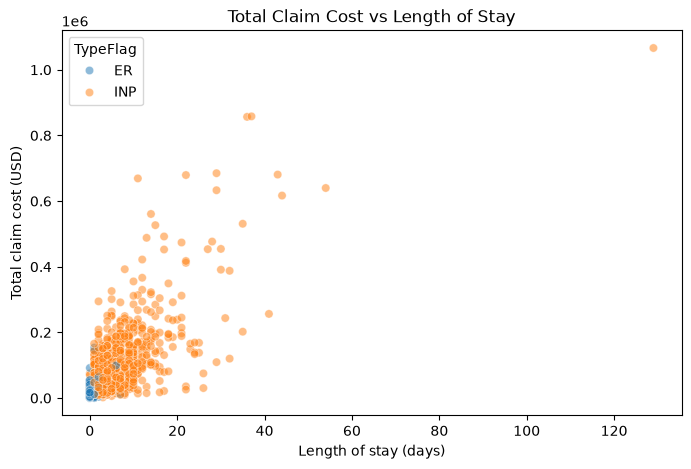

In [42]:
# LengthOfStay in days (formally part of Part E, computed here for run order)
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days

# Aggregate to one row per claim: sum the line items, keep the stay length and type
claims = (df.groupby('MedicalClaim')
            .agg(ClaimTotal=('TotalExpenses', 'sum'),
                 LengthOfStay=('LengthOfStay', 'first'),
                 TypeFlag=('TypeFlag', 'first'))
            .reset_index())
print('Claims:', len(claims))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=claims, x='LengthOfStay', y='ClaimTotal',
                hue='TypeFlag', alpha=0.5)
plt.title('Total Claim Cost vs Length of Stay')
plt.xlabel('Length of stay (days)')
plt.ylabel('Total claim cost (USD)')
plt.show()

*TODO -  describe the relationship you see between stay length and claim cost, and how ER claims differ from INP claims on this plot.*

Length of stay is strongly linked to claim cost (r ≈ 0.79 overall), with inpatient claims driving nearly all long‑stay, high‑cost cases. ER visits cluster at short stays and low costs, while inpatient claims stretch upward with longer, more expensive stays. The pattern trend is clear going up to the right dense at the bottom but clearly lean tomowards long stays cost more than short,   It also showstere is exceptions in both long says with flat ish cost and equivant very high cost for oher stays .  It  is clear but duration matters, depending on treatment.

## Part E - Functions & Derived Columns

1. Write a function compute_age(birthdate, ref_date) that returns age in completed years. Apply it to create an Age column using a reference date of 2020-12-31.

2. Create a LengthOfStay column (in days) from EndDate − StartDate.

3. Write a function that maps Age into a band ('<40', '40–64', '65–79', '80+') and apply it to create an AgeBand column. Report the count of line items in each band.

4. Write a function cost_tier(x) that returns 'Low' (<$500), 'Medium' ($500–4,999), or 'High' (≥$5,000), and apply it to TotalExpenses.

**PE-E1. Age in completed years at 2020-12-31.**

In [43]:
# Reusable function: age in completed years at a reference date
def compute_age(birthdate, ref_date):
    """Return age in completed years at ref_date."""
    return (ref_date.year - birthdate.year
            - ((ref_date.month, ref_date.day) < (birthdate.month, birthdate.day)))

ref_date = pd.Timestamp('2020-12-31')
df['Age'] = df['BirthDate'].apply(lambda b: compute_age(b, ref_date))
df['Age'].describe()

count    52563.000000
mean        72.159123
std         12.230098
min         21.000000
25%         67.000000
50%         73.000000
75%         81.000000
max         99.000000
Name: Age, dtype: float64

**PE-E2. LengthOfStay (days) from EndDate − StartDate.** (Created in Part D3 for run order; shown again here.)

In [44]:
# LengthOfStay in whole days
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days
df['LengthOfStay'].describe()

count    52563.000000
mean         3.869109
std          6.008744
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        129.000000
Name: LengthOfStay, dtype: float64

**PE-E3. Age bands.**

In [45]:
# Map each age into a band and count line items per band
def age_band(age):
    """Return the age band for an age in years."""
    if age < 40:
        return '<40'
    elif age < 65:
        return '40–64'
    elif age < 80:
        return '65–79'
    else:
        return '80+'

df['AgeBand'] = df['Age'].apply(age_band)
df['AgeBand'].value_counts()

AgeBand
65–79    27781
80+      14601
40–64     9444
<40        737
Name: count, dtype: int64

**PE-E4. Cost tiers.**

In [46]:
# Assign each line item to a cost tier by value
def cost_tier(x):
    """Return 'Low' (<$500), 'Medium' ($500–4,999) or 'High' (>=$5,000)."""
    if x < 500:
        return 'Low'
    elif x < 5000:
        return 'Medium'
    else:
        return 'High'

df['CostTier'] = df['TotalExpenses'].apply(cost_tier)
df['CostTier'].value_counts()

CostTier
Low       22981
Medium    22948
High       6634
Name: count, dtype: int64

## Part F - Merge

1. Load MemberReference.csv from its source URL (above) and merge it onto the claims DataFrame on MemberID using a left join.

2. Confirm the merge preserved the original row count and report how many rows (if any) failed to match a PlanType.

3. Group the merged data by PlanType and compute mean TotalExpenses. Which plan has the highest average line-item cost?

4. Produce a seaborn boxplot of TotalExpenses by PlanType and write one sentence interpreting it.



**DF-F1. Load the member reference table and left-join it on MemberID.**

In [47]:
# Load the member reference table from its source URL
member_url = ('https://raw.githubusercontent.com/thousandoaks/'
              'Python4DS-I/refs/heads/main/datasets/MemberReference.csv')
member_ref = pd.read_csv(member_url)
print('Member reference shape:', member_ref.shape)

# Left join keeps every claim line item, adding plan details where they match
merged = df.merge(member_ref, on='MemberID', how='left')
merged.head()

Member reference shape: (1757, 3)


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,...,RevenueCode,TypeFlag,BirthDate,TotalExpenses,LengthOfStay,Age,AgeBand,CostTier,PlanType,EnrollmentYear
0,634363,e659f3f4,6a380a28,6f943458,c1e3436737c77899,18,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,15.148,0,53,40–64,Low,Silver,2017
1,634364,e659f3f4,6a380a28,6f943458,c1e3436737c77899,21,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,3.073,0,53,40–64,Low,Silver,2017
2,634387,e659f3f4,6a380a28,6f943458,c1e3436737c77899,10,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,305.0,ER,1967-05-13,123.900,0,53,40–64,Low,Silver,2017
3,634388,e659f3f4,6a380a28,6f943458,c1e3436737c77899,20,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,7.511,0,53,40–64,Low,Silver,2017
4,634389,e659f3f4,6a380a28,6f943458,c1e3436737c77899,19,04b77561,HOSPITAL,2020-01-08,2020-01-08,...,636.0,ER,1967-05-13,8.631,0,53,40–64,Low,Silver,2017


**DF-F2. Verify the merge.**

In [48]:
# Integrity checks: row count preserved, and count of rows without a PlanType match
print('Original rows:', len(df))
print('Merged rows:  ', len(merged))
print('Row count preserved:', len(merged) == len(df))
print('Rows with no PlanType match:', merged['PlanType'].isna().sum())

Original rows: 52563
Merged rows:   52563
Row count preserved: True
Rows with no PlanType match: 0


**DF-F3. Mean TotalExpenses by PlanType.**

In [49]:
# Average line-item cost per plan, highest first
merged.groupby('PlanType')['TotalExpenses'].mean().sort_values(ascending=False).round(2)

PlanType
Gold        2854.07
Platinum    2789.14
Silver      2757.07
Bronze      2634.32
Name: TotalExpenses, dtype: float64

*TODO - which plan has the highest average line-item cost, and whether the differences between plans look large or small.*

PlanType differences are minimal as you can see from above 'Gold' has the highest average line‑item cost at $2,854, but is only about $220  above Bronze, and all four plans fall within a tight $2,634–$2,854 range. There’s no clean tier pattern either  'Gold sits above 'Platinum'  this reenfocs that  shows plan type isn’t a meaningful cost driver. In contrast to , 'care type', 'length of stay', and diagnosis showed and produced a  far larger cost variation on the charts and data , making PlanType largely irrelevant to how much an individual line item costs.

**DF-F4. Boxplot of TotalExpenses by PlanType.**

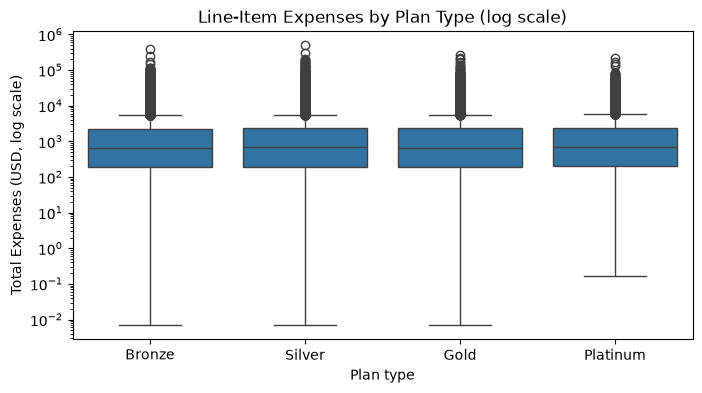

In [50]:
# Boxplot of costs by plan; log scale so medians are visible despite outliers
plt.figure(figsize=(8, 4))
order = ['Bronze', 'Silver', 'Gold', 'Platinum']
sns.boxplot(data=merged[merged['TotalExpenses'] > 0], x='PlanType',
            y='TotalExpenses', order=order)
plt.yscale('log')
plt.title('Line-Item Expenses by Plan Type (log scale)')
plt.xlabel('Plan type')
plt.ylabel('Total Expenses (USD, log scale)')
plt.show()

*TODO - how similar or different the plans' cost distributions look.*

The four boxplots are umistakablely similar  'Bronze', 'Silver', 'Gold' and 'Platinum' all share almost the same median, nearly the same box height (interquartile range), and the same long upper tail of high-cost outliers stretching up toward $10⁵–$10⁶. Unlike the INP-vs-ER boxplot, where one box sat clearly above the other, here the boxes visually line up at the same level , so plan type barely shifts the cost distribution.   The takeway is the plan tier is a weak cowst predictor of line item cost.